In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats



In [25]:
df=pd.read_csv('mushroom_en.csv')
# Clean column names
df.columns = ['Year', 'Harvested_Area_sqft', 'Harvested_Area_acres', 
              'Production_lbs', 'Production_tonnes', 'Value_dollars', 
              'Price_cents_lb', 'Price_dollars_tonne']
df.head()

,Year,Harvested_Area_sqft,Harvested_Area_acres,Production_lbs,Production_tonnes,Value_dollars,Price_cents_lb,Price_dollars_tonne
0,2024,"39,901",916,"169,742","76,994","468,783",276.2,"6,088.6"
1,2023,"39,868",915,"163,020","73,945","450,528",276.4,"6,092.8"
2,2022,"39,257",901,"157,144","71,279","439,267",279.5,"6,162.6"
3,2021,"36,039",827,"156,780","71,114","417,415",266.2,"5,869.6"
4,2020,"33,430",767,"147,240","66,787","369,977",251.3,"5,539.7"


In [33]:


# Column names
df.columns = ['Year', 'Harvested_Area_sqft', 'Harvested_Area_acres', 
              'Production_lbs', 'Production_tonnes', 'Value_dollars', 
              'Price_cents_lb', 'Price_dollars_tonne']

# Convert all object columns to numeric
for col in df.columns:
    if df[col].dtype == 'O':  # object type
        # Remove commas if present and convert to numeric
        df[col] = pd.to_numeric(df[col].str.replace(',', ''), errors='coerce')
    else:
        # If not object, make sure it's float
        df[col] = df[col].astype(float)

# Check the dtypes
print(df.dtypes)
df.to_csv("mushroom_2.csv", index=False)


Year                    float64
Harvested_Area_sqft     float64
Harvested_Area_acres    float64
Production_lbs          float64
Production_tonnes       float64
Value_dollars           float64
Price_cents_lb          float64
Price_dollars_tonne     float64
dtype: object


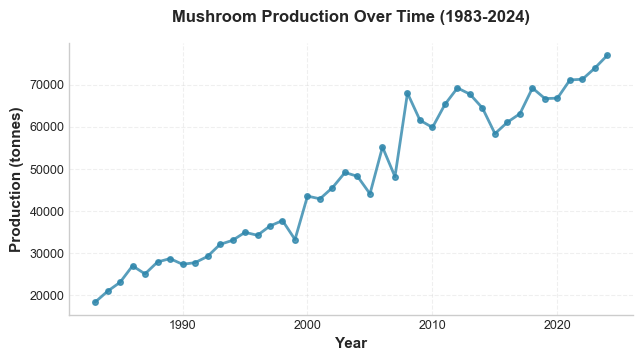

In [ ]:
# Create figure with subplots following Cleveland & McGill's perceptual principles
fig = plt.figure(figsize=(16, 12))

# A plot to depict the time series of Production 
ax1 = plt.subplot(3, 2, 1)
ax1.plot(df['Year'], df['Production_tonnes'], linewidth=2, marker='o', 
         markersize=4, color='#2E86AB', alpha=0.8)
ax1.set_xlabel('Year', fontsize=11, fontweight='bold')
ax1.set_ylabel('Production (tonnes)', fontsize=11, fontweight='bold')
ax1.set_title('Mushroom Production Over Time (1983-2024)', 
              fontsize=12, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)



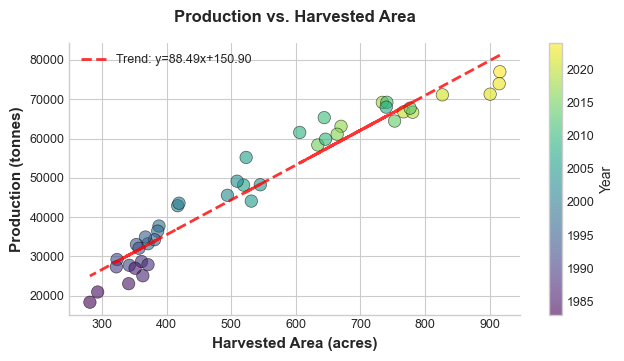

In [ ]:
fig = plt.figure(figsize=(16, 12))
# Scatterplot of Harvested Area vs Production 
ax3 = plt.subplot(3, 2, 3)
scatter = ax3.scatter(df['Harvested_Area_acres'], df['Production_tonnes'], 
                      c=df['Year'], cmap='viridis', s=80, alpha=0.6, 
                      edgecolors='black', linewidth=0.5)
# Add regression line
z = np.polyfit(df['Harvested_Area_acres'], df['Production_tonnes'], 1)
p = np.poly1d(z)
ax3.plot(df['Harvested_Area_acres'], p(df['Harvested_Area_acres']), 
         "r--", alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
ax3.set_xlabel('Harvested Area (acres)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Production (tonnes)', fontsize=11, fontweight='bold')
ax3.set_title('Production vs. Harvested Area', fontsize=12, fontweight='bold', pad=15)
ax3.legend(loc='upper left', fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Year', fontsize=10)